# Roadmap §1.1: closing the format half-gaps

v15.5.0 closes six holes in already-shipped formats. [`07_calculix_frd.ipynb`](07_calculix_frd.ipynb) covers `.frd`'s binary layout, the `.dat` tabular file and the new `tensor_invariants` data operation; this notebook covers the other four, each with a small self-contained mesh built inline (no external fixture needed) and graphical output.

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

import meshioplusplus as mp

# Head-less, static rendering (no display / live server needed).
pv.OFF_SCREEN = True
pv.set_jupyter_backend('static')

TMP = tempfile.mkdtemp()


def to_grid(mesh):
    """meshio++ Mesh -> PyVista grid via a temporary .vtu."""
    path = os.path.join(TMP, 'render.vtu')
    mp.write(path, mesh)
    return pv.read(path)


def gallery(items, ncols=2, size=(760, 500)):
    """Render `(mesh, scalar, title, camera)` items side by side, or with matplotlib when GL is unavailable."""
    nrows = -(-len(items) // ncols)
    fig = plt.figure(figsize=(6.0 * ncols, 4.6 * nrows))
    for k, (mesh, scalar, title, camera) in enumerate(items, start=1):
        ax = fig.add_subplot(nrows, ncols, k)
        try:
            grid = to_grid(mesh)
            pl = pv.Plotter(off_screen=True, window_size=size)
            pl.add_mesh(grid, scalars=scalar, cmap='turbo', show_edges=True, edge_color='#333333',
                        line_width=0.8, scalar_bar_args={'title': scalar, 'vertical': False,
                                                        'position_x': 0.2, 'position_y': 0.02, 'width': 0.6})
            pl.camera_position = camera
            pl.camera.zoom(1.0)
            img = pl.screenshot(return_img=True)
            pl.close()
            ax.imshow(img)
        except Exception as exc:  # pragma: no cover - head-less GL fallback
            print('PyVista render skipped:', exc)
            ax = fig.add_subplot(nrows, ncols, k, projection='3d')
            p = mesh.points
            values = mesh.cell_data[scalar][0] if scalar in mesh.cell_data else mesh.point_data[scalar]
            values = np.linalg.norm(values, axis=1) if values.ndim > 1 else values
            if len(values) == len(p):
                ax.scatter(p[:, 0], p[:, 1], p[:, 2], s=8, c=values, cmap='turbo')
            else:
                ax.scatter(p[:, 0], p[:, 1], p[:, 2], s=8, c='steelblue')
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## SU2 multizone (`NZONE=`)

A single `.su2` file can hold several independent zones, never welded — each solved as its own mesh. Two unit-square quad plates, offset along `x`, become zones 0 and 1; `cell_data["su2:zone"]` names each cell's zone on the way back in.

zones written: [0, 1]
points (unwelded, so 16 not 12): 16


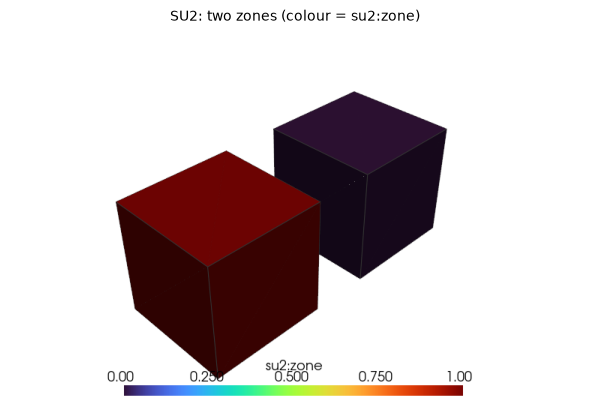

In [2]:
def plate(x0):
    pts = np.array([[x0, 0, 0], [x0 + 1, 0, 0], [x0 + 1, 1, 0], [x0, 1, 0],
                    [x0, 0, 1], [x0 + 1, 0, 1], [x0 + 1, 1, 1], [x0, 1, 1]], dtype=float)
    cells = [('hexahedron', np.array([[0, 1, 2, 3, 4, 5, 6, 7]]))]
    return mp.Mesh(pts, cells)


zone0, zone1 = plate(0.0), plate(1.5)
su2_path = os.path.join(TMP, 'zones.su2')
mp.su2.write(su2_path, zone0)  # first write establishes the file; zones stack via su2:zone below

# Build the two-zone mesh directly: concatenate points/cells, tag su2:zone.
pts = np.vstack([zone0.points, zone1.points])
cells = [('hexahedron', np.vstack([zone0.cells[0].data, zone1.cells[0].data + len(zone0.points)]))]
two_zone = mp.Mesh(pts, cells, cell_data={'su2:zone': [np.array([0, 1])]})
mp.su2.write(su2_path, two_zone)

back = mp.su2.read(su2_path)
print('zones written:', sorted(set(back.cell_data['su2:zone'][0].tolist())))
print('points (unwelded, so 16 not 12):', len(back.points))

gallery([(back, 'su2:zone', 'SU2: two zones (colour = su2:zone)', 'iso')], ncols=1)

## Tecplot multiple zones

`write_tecplot` now writes one `ZONE` per cell block instead of requiring a single type. A triangle fan and a quad strip, over the same point cloud, become zone 0 and zone 1; the second reuses zone 1's points via `VARSHARELIST` rather than duplicating them, and each zone becomes its own named [region](../../doc/regions.md).

points (shared, not duplicated): 6
cell blocks: ['triangle', 'quad']
zone regions: [('block_0', 'cell'), ('block_1', 'cell')]


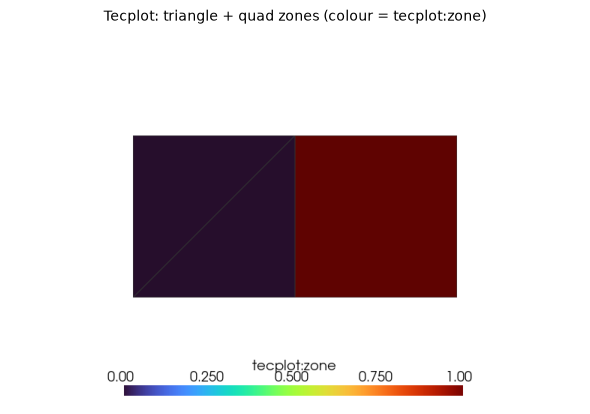

In [3]:
pts = np.array([[0, 0, 0], [1, 0, 0], [2, 0, 0], [0, 1, 0], [1, 1, 0], [2, 1, 0]], dtype=float)
tris = np.array([[0, 1, 4], [0, 4, 3]])
quads = np.array([[1, 2, 5, 4]])
hybrid = mp.Mesh(pts, [('triangle', tris), ('quad', quads)])

tec_path = os.path.join(TMP, 'zones.tec')
mp.tecplot.write(tec_path, hybrid)
back = mp.tecplot.read(tec_path)

print('points (shared, not duplicated):', len(back.points))
print('cell blocks:', [c.type for c in back.cells])
print('zone regions:', [(r.name, r.kind) for r in back.regions])

gallery([(back, 'tecplot:zone', 'Tecplot: triangle + quad zones (colour = tecplot:zone)', 'xy')], ncols=1)

## EnSight Gold variable write

Reading an EnSight `VARIABLE` section has worked since v11.3.0; `write_ensight` now writes one too — scalar, vector, `tensor symm`/`tensor asym` point and cell data, and a single `field_data` scalar as `constant per case`. EnSight's own `tensor symm` component order differs from meshio++'s in its last two components (confirmed against ParaView's reader), so the round trip below is the real test, not just a visual one.

temp round-trips: True
sig (tensor symm) round-trips: True
field_data: {'inlet_velocity': [12.5]}


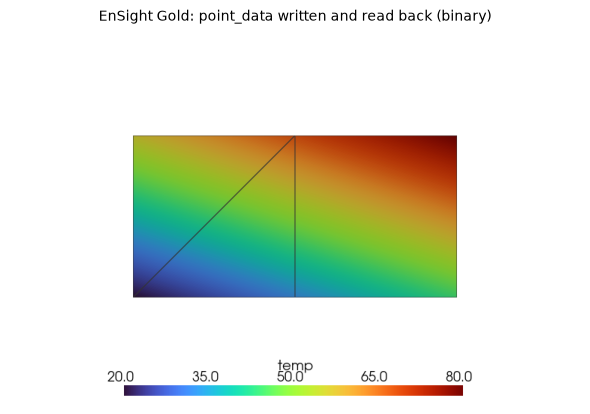

In [4]:
n = len(hybrid.points)
temp = np.linspace(20.0, 80.0, n)
sig = np.zeros((n, 6))
sig[:, 0] = temp  # xx component only, so 'peak' below reads cleanly off the colour map

tagged = mp.Mesh(hybrid.points, hybrid.cells, point_data={'temp': temp, 'sig': sig},
                 field_data={'inlet_velocity': np.array([12.5])})

ensight_path = os.path.join(TMP, 'case.case')
mp.ensight.write(ensight_path, tagged, binary=True)
back = mp.ensight.read(ensight_path)

print('temp round-trips:', np.allclose(back.point_data['temp'], temp))
print('sig (tensor symm) round-trips:', np.allclose(back.point_data['sig'], sig))
print('field_data:', {k: v.tolist() for k, v in back.field_data.items()})

gallery([(back, 'temp', 'EnSight Gold: point_data written and read back (binary)', 'xy')], ncols=1)

## OpenFOAM binary write

Binary read has worked for a while; `write_openfoam` (and `meshioplusplus.openfoam.write(..., binary=True)`) now writes one too, at a chosen `label_bits`/`scalar_bits` width. A 2×2×2 grid of hexahedra, written both ways, reads back to the identical mesh either way — and the binary file is measurably smaller.

points match: True
cells match: True
points file size: ASCII 1011 B, binary 1485 B


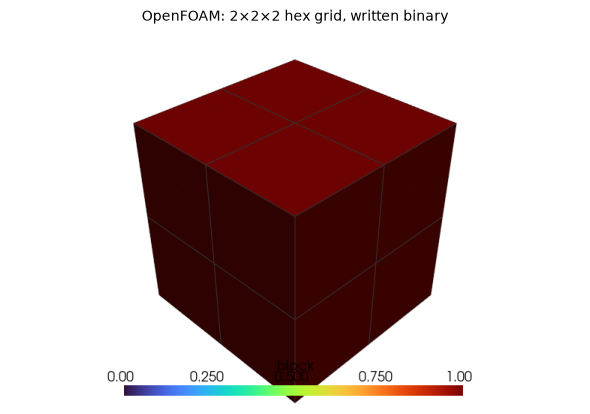

In [5]:
def hex_grid(n):
    p = n + 1
    pts = np.array([[i, j, k] for i in range(p) for j in range(p) for k in range(p)], dtype=float)

    def nid(i, j, k):
        return (i * p + j) * p + k

    rows = [[nid(i, j, k), nid(i + 1, j, k), nid(i + 1, j + 1, k), nid(i, j + 1, k),
             nid(i, j, k + 1), nid(i + 1, j, k + 1), nid(i + 1, j + 1, k + 1), nid(i, j + 1, k + 1)]
            for i in range(n) for j in range(n) for k in range(n)]
    return mp.Mesh(pts, [('hexahedron', np.array(rows))])


grid = hex_grid(2)
ascii_case = os.path.join(TMP, 'ascii', 'case.foam')
binary_case = os.path.join(TMP, 'binary', 'case.foam')
mp.openfoam.write(ascii_case, grid, binary=False)
mp.openfoam.write(binary_case, grid, binary=True)

a = mp.openfoam.read(ascii_case)
b = mp.openfoam.read(binary_case)
print('points match:', np.allclose(a.points, b.points))
print('cells match:', np.array_equal(a.cells[0].data, b.cells[0].data))

ascii_size = os.path.getsize(os.path.join(os.path.dirname(ascii_case), 'constant', 'polyMesh', 'points'))
binary_size = os.path.getsize(os.path.join(os.path.dirname(binary_case), 'constant', 'polyMesh', 'points'))
print(f'points file size: ASCII {ascii_size} B, binary {binary_size} B')

b.cell_data['block'] = [np.full(len(c.data), i) for i, c in enumerate(b.cells)]
gallery([(b, 'block', 'OpenFOAM: 2×2×2 hex grid, written binary', 'iso')], ncols=1)

## Onward

Each format's own page has the full detail: [SU2](../../doc/formats/su2.md#multizone-nzone), [Tecplot](../../doc/formats/tecplot.md#multiple-zones), [EnSight Gold](../../doc/formats/ensight.md#variable-write), [OpenFOAM](../../doc/formats/openfoam.md#binary-write). All four round-trip through the CLI and MCP the same way every other format does — nothing above is Python-only.